# Cvičenie 3 - Lineárna regresia

<object data="https://miroslava.matejova.website.tuke.sk/IE/IE/cvicenie3.pdf" type="application/pdf" width="700px" height="700px">
    <embed src="https://miroslava.matejova.website.tuke.sk/IE/IE/cvicenie3.pdf">
        <p> Cvičenie v PDF dostupné: <a href="https://miroslava.matejova.website.tuke.sk/IE/IE/cvicenie3.pdf">TU!</a></p>
    </embed>
</object>

V `R` môžeme parametre lineárneho modelu vypočítať pomocou funkcie `lm`.

Nasledujúci príklad načíta dátovú množinu `Iris`, vyfiltruje iba príklady z triedy `setosa`, a vypočíta lineárny
model s jedným **vstupným** atribútom `iris$Sepal.Length` pre **výstupnú** hodnotu `iris$Sepal.Width`

In [1]:
data(iris)
setosa <- iris[iris$Species == "setosa", ]
attach(setosa)

In [2]:
setosa

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa
7,4.6,3.4,1.4,0.3,setosa
8,5.0,3.4,1.5,0.2,setosa
9,4.4,2.9,1.4,0.2,setosa


In [3]:
sepal_lm <- lm(Sepal.Width ~ Sepal.Length) # y = b0 + b1x1 + b2x2 + b3x3 + ... + bmxm
sepal_lm 


Call:
lm(formula = Sepal.Width ~ Sepal.Length)

Coefficients:
 (Intercept)  Sepal.Length  
     -0.5694        0.7985  


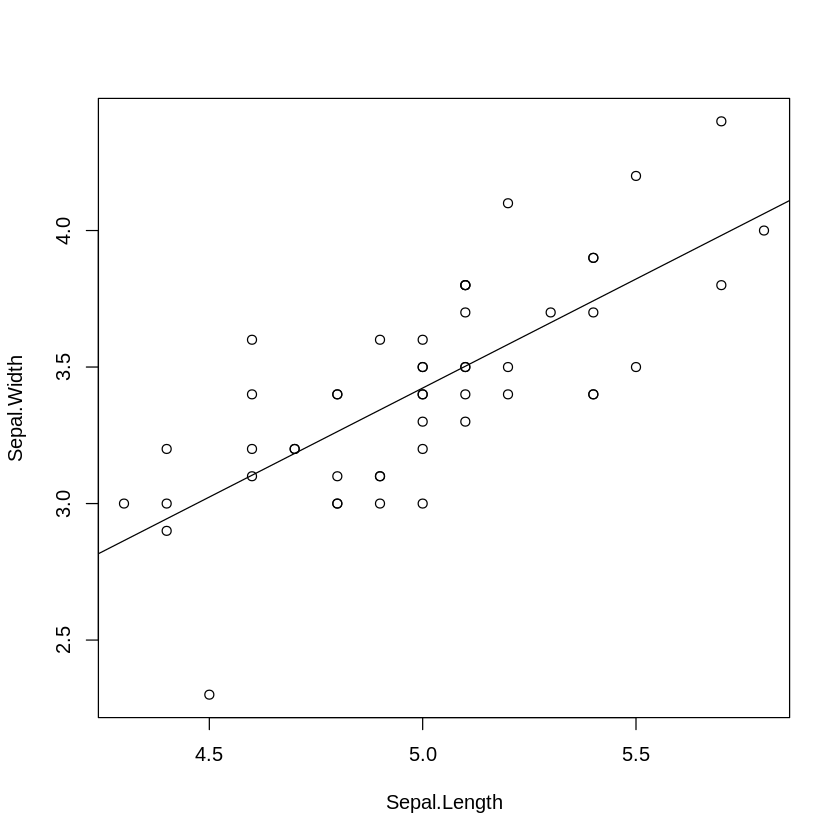

In [4]:
plot(Sepal.Length, Sepal.Width)
abline(sepal_lm)

V príklade je vykreslená regresná priamka, ktorá určuje **predikovanú hodnotu f(x)** . Ďalšie
vstupné atribúty je možné pridať do modelu pomocou operátora `+`, napr. `lm(Y ~ X1 + X2 +
X3)` je lineárny model, ktorý **predikuje atribút `Y`** na základe troch **vstupných** atribútov `X1`, `X2`
a `X3`.

Pomocou funkcie summary si môžeme vypísať základné štatistiky o rezíduách a parametroch
modelu:

In [6]:
summary(sepal_lm)


Call:
lm(formula = Sepal.Width ~ Sepal.Length)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.72394 -0.18273 -0.00306  0.15738  0.51709 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -0.5694     0.5217  -1.091    0.281    
Sepal.Length   0.7985     0.1040   7.681 6.71e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2565 on 48 degrees of freedom
Multiple R-squared:  0.5514,	Adjusted R-squared:  0.542 
F-statistic: 58.99 on 1 and 48 DF,  p-value: 6.71e-10


#### Popis funkcie `summary`

Rozdiely medzi predikovanou hodnotu a skutočnou hodnotou `y` sa označujú ako **rezíduá**.
V časti `Residuals` sú informácie o základných štatistikách rezíduí. Tieto rozdiely by mali byť
v absolútnej hodnote čo najmenšie. Rezíduá pre všetky trénovacie príklady môžete získať
pomocou funkcie `residuals`

In [7]:
residuals(sepal_lm)

1           2           3           4           5           6 
-0.00306166 -0.34335600  0.01634966 -0.00379751  0.17679117  0.15737985 
          7           8           9          10          11          12 
 0.29620249 -0.02320883 -0.04409185 -0.24335600 -0.04262015  0.13649683 
         13          14          15          16          17          18 
-0.26350317  0.13576098 -0.06203147  0.41782136  0.15737985 -0.00306166 
         19          20          21          22          23          24 
-0.18217864  0.29693834 -0.34262015  0.19693834  0.49620249 -0.20306166 
         25          26          27          28          29          30 
 0.13649683 -0.42320883 -0.02320883 -0.08291449 -0.18291449  0.01634966 
         31          32          33          34          35          36 
-0.16350317 -0.34262015  0.51708551  0.37752702 -0.24335600 -0.22320883 
         37          38          39          40          41          42 
-0.32247298  0.25664400  0.05590815 -0.10306166  0.07679117 -0.72394468 
         43          44          45          46          47          48 
 0.25590815  0.07679117  0.29693834 -0.26350317  0.29693834  0.09620249 
         49          50 
 0.03723268 -0.12320883

Celkovú chybu (sumu štvorcov rezíduí – z čoho sa minimalizovanie kvadratickej chybovej
funkcie označuje metóda najmenších štvorcov) môžete vypísať funkciou:

In [8]:
deviance(sepal_lm)

[1] 3.158675

#### Coefficients

V prehľade viete ďalej zistiť hodnoty samotných parametrov v časti `Coefficients`. Parameter
$\beta_0$ sa označuje ako `Intercept`, pretože určuje v ktorom bode bude regresná priamka **pretínať
os Y**. Keďže ostatné parametre $\beta_1 ... \beta_m $ zodpovedajú jednotlivým **vstupným** atribútom,
parametre sú označené názvom zodpovedajúceho atribútu, napr. `Sepal.Length`. 

To, ako jedôležitý atribút pre výslednú predikciu určuje absolútna veľkosť zodpovedajúceho
parametra, ak sa parameter blíži k 0, atribút je možné z modelu vynechať bez toho aby sa
výrazne zmenila predikcia. Významnosť atribútov sa testuje štatistickým testom ktorého
hypotéza je, že sa zodpovedajúci parameter = 0. Čím menšia je táto pravdepodobnosť, tým
dôležitejší je daný atribút (čo je označené vo výpise aj hviezdičkami, *** dôležitý atribút, **
stredne dôležitý, atď.)

#### Predikcia

Ak chcete vypočítať predikovanú hodnotu pre nové vstupné dáta, môžete použiť funkciu
`predict`:

In [10]:
predict(sepal_lm, newdata = data.frame(Sepal.Length=6))

1 
4.221737

Pomocou predikt môžeme vypočítať aj hodnoty pre viac príkladov naraz.

Podľa variancie vstupných dát vieme pri lineárnej regresii odhadnúť aj varianciu parametrov,
ktorá je uvedená ako štandardná odchýlka pri výpise summary pre každý parameter. Keďže
parametre sú odhadované iba s určitou varianciou, aj samotná predikcia je len odhad pre
ktorý môžeme určiť varianciu v akom rozsahu sa bude predikovaná hodnota
najpravdepodobnejšie pohybovať. Tento interval si môžete vypísať pomocou funkcie
`predict`:

In [11]:
predict(sepal_lm, newdata = data.frame(Sepal.Length=6), interval="prediction")

,fit,lwr,upr
1,4.221737,3.660913,4.782561


Pomocou `predict` je potom možné zobraziť aj intervaly spoľahlivosti pre predikciu (v tomto
intervale by sa mala s veľkou pravdepodobnosťou pohybovať skutočná hodnota). 

Najprv si
vygenerujeme vstupné dáta (interval od 4 do 6 s krokom 0.25) a potom vypočítame
predikciu aj s intervalom:

In [12]:
lengths <- seq(from=4, to=6, by=0.25)
predictions <- predict(sepal_lm, newdata =data.frame(Sepal.Length=lengths), interval="prediction")

In [13]:
lengths

[1] 4.00 4.25 4.50 4.75 5.00 5.25 5.50 5.75 6.00

In [14]:
predictions

,fit,lwr,upr
1,2.624681,2.062922,3.186439
2,2.824313,2.279956,3.368669
3,3.023945,2.492402,3.555488
4,3.223577,2.699922,3.747231
5,3.423209,2.902294,3.944123
6,3.622841,3.099437,4.146245
7,3.822473,3.291423,4.353523
8,4.022105,3.478471,4.565739
9,4.221737,3.660913,4.782561


Hodnoty si zobrazíme v grafe ako interval pomocou horného a spodného ohraničenia:

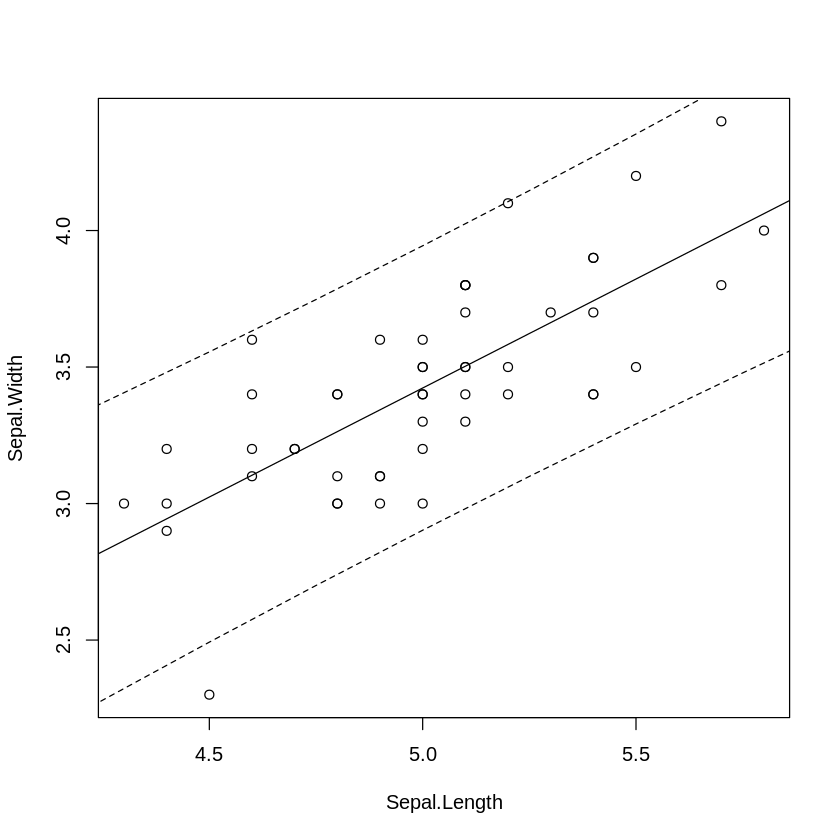

In [15]:
plot(Sepal.Length, Sepal.Width)
lines(predictions[,1] ~ lengths, col=1)
lines(predictions[,2] ~ lengths, col=1, lty=2)
lines(predictions[,3] ~ lengths, col=1, lty=2)

Všimnite si, že sa pri krajných hodnotách 4 a 6 interval mierne rozširuje (tzn. pre krajné
vstupné hodnoty môže byť predikovaná hodnota vypočítaná s väčšou varianciou).

# Úlohy na cvičení

1. Načítajte dátovú množinu `Iris`, odfiltrujte príklady z triedy `setosa` a vytvorte lineárny
model predikujúci atribút `Petal.Width` pre vstupný atribút `Petal.Length`. Vizualizujte
dáta a regresnú priamku

In [23]:
data = iris[iris$Species == 'setosa', ]
data

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa
7,4.6,3.4,1.4,0.3,setosa
8,5.0,3.4,1.5,0.2,setosa
9,4.4,2.9,1.4,0.2,setosa


In [24]:
petal_lm <- lm(data$Petal.Width ~ data$Petal.Length) # y = b0 + b1x1 + b2x2 + b3x3 + ... + bmxm
petal_lm 


Call:
lm(formula = data$Petal.Width ~ data$Petal.Length)

Coefficients:
      (Intercept)  data$Petal.Length  
         -0.04822            0.20125  


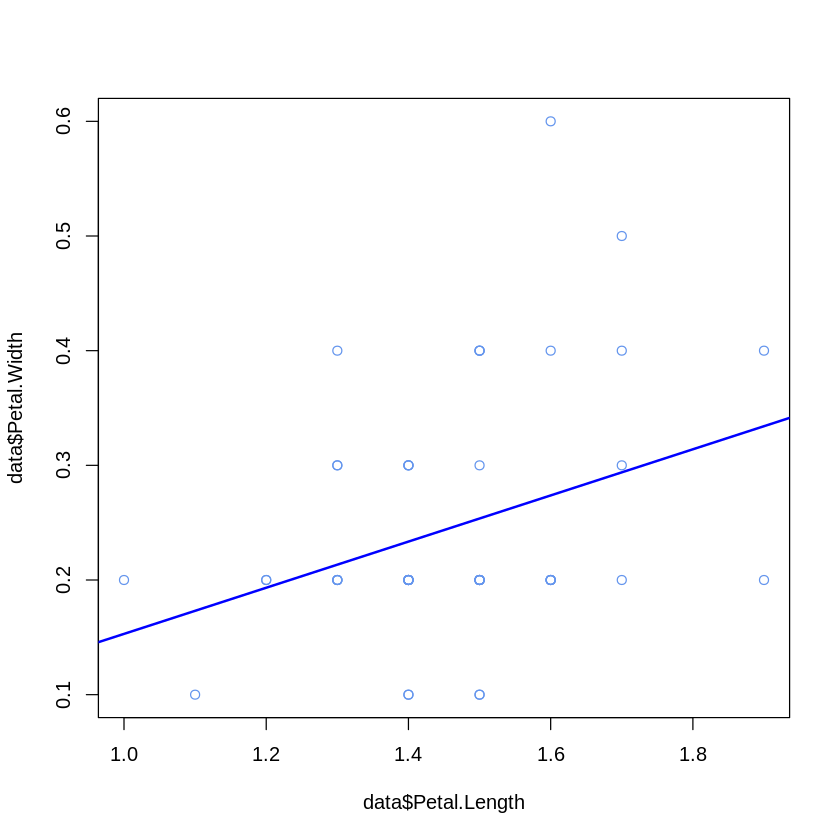

In [27]:
plot(data$Petal.Length, data$Petal.Width, col = "cornflowerblue")
abline(petal_lm, col = "blue", lwd=2)

2. Vypočítajte celkovú sumu kvadrátov rezíduí modelu z predošlého príkladu a
korelačný koeficient medzi vstupným a výstupným atribútom. Zobrazte histogram
rezíduí.

In [29]:
suma = sum(residuals(petal_lm)^2)
suma

[1] 0.4843497

In [30]:
cor(data$Petal.Length, data$Petal.Width)

[1] 0.33163

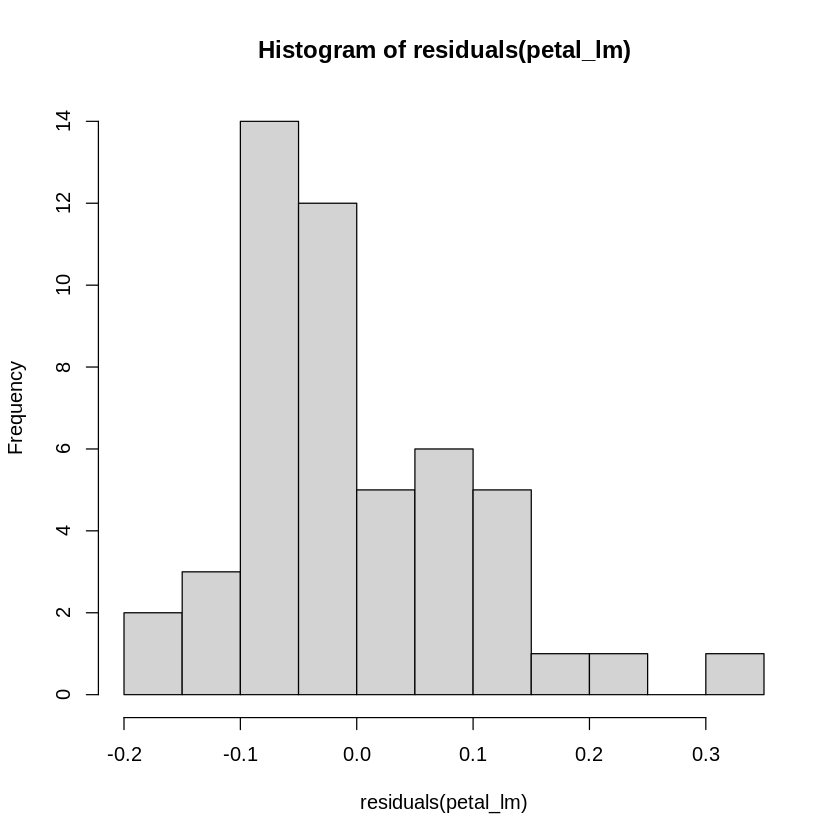

In [31]:
hist(residuals(petal_lm))

3. Vypočítajte predikciu a interval spoľahlivosti pre trénovacie dáta. Zobrazte graf s
dátami, regresnou priamkou a intervalovými hranicami.

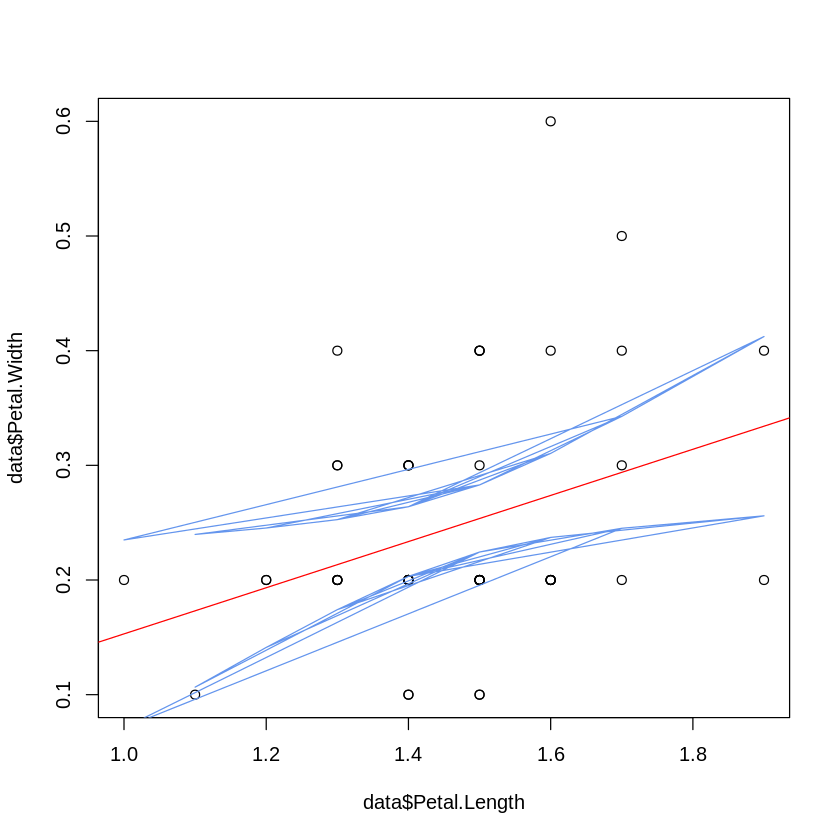

In [53]:
p = predict(petal_lm, newdata = data, interval="confidence")
plot(data$Petal.Length, data$Petal.Width)
abline(petal_lm, col = "red", pch=3)
lines(data$Petal.Length, p[, 2], col="cornflowerblue")
lines(data$Petal.Length, p[, 3], col="cornflowerblue")
#lines(p[,2] ~ lengths, col=1, lty=2)
#lines(p[,3] ~ lengths, col=1, lty=2)

4. Z množiny iris odfiltrujte iba príklady z triedy versicolor, vypočítajte predikciu a
intervalové odhady. Zobrazte graf s dátami, regresnou priamkou, a intervalovými
hranicami.

In [56]:
vc = iris[iris$Species == "versicolor", ]
vc

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
51,7.0,3.2,4.7,1.4,versicolor
52,6.4,3.2,4.5,1.5,versicolor
53,6.9,3.1,4.9,1.5,versicolor
54,5.5,2.3,4.0,1.3,versicolor
55,6.5,2.8,4.6,1.5,versicolor
56,5.7,2.8,4.5,1.3,versicolor
57,6.3,3.3,4.7,1.6,versicolor
58,4.9,2.4,3.3,1.0,versicolor
59,6.6,2.9,4.6,1.3,versicolor


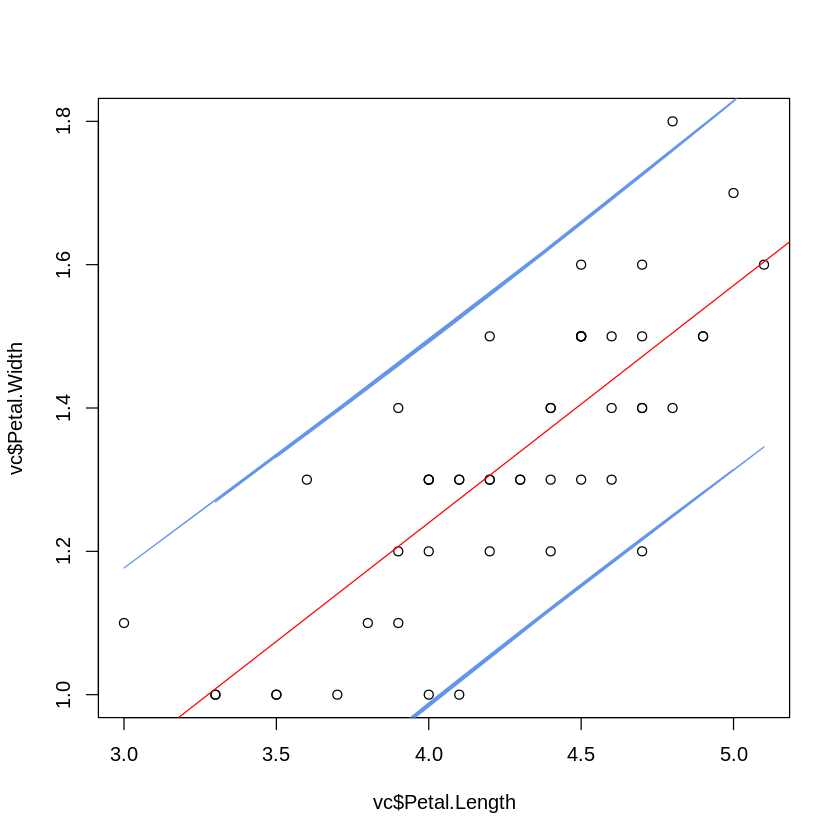

In [63]:
petal_lm = lm(vc$Petal.Width ~ vc$Petal.Length)
pr = predict(petal_lm, newdata = vc, interval="prediction")
plot(vc$Petal.Width ~ vc$Petal.Length)
abline(petal_lm, col = "red", pch=3)
lines(vc$Petal.Length, pr[, 2], col="cornflowerblue")
lines(vc$Petal.Length, pr[, 3], col="cornflowerblue")

5. Vytvorte rozšírený model, ktorý bude mať okrem `Petal.Length` na vstupe aj atribút
`Sepal.Width`. Zistite, ktoré parametre modelu sú štatisticky významné, a porovnajte
chybu rozšíreného modelu s predchádzajúcim príkladom.

In [66]:
model = lm(vc$Petal.Width ~ vc$Petal.Length + vc$Sepal.Width)
model
summary(petal_lm)
summary(model)


Call:
lm(formula = vc$Petal.Width ~ vc$Petal.Length + vc$Sepal.Width)

Coefficients:
    (Intercept)  vc$Petal.Length   vc$Sepal.Width  
        -0.3252           0.2543           0.2050  



Call:
lm(formula = vc$Petal.Width ~ vc$Petal.Length)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.273031 -0.073373 -0.006479  0.086271  0.295231 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -0.08429    0.16070  -0.525    0.602    
vc$Petal.Length  0.33105    0.03750   8.828 1.27e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1234 on 48 degrees of freedom
Multiple R-squared:  0.6188,	Adjusted R-squared:  0.6109 
F-statistic: 77.93 on 1 and 48 DF,  p-value: 1.272e-11



Call:
lm(formula = vc$Petal.Width ~ vc$Petal.Length + vc$Sepal.Width)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.270959 -0.064119 -0.005774  0.072671  0.248525 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -0.32521    0.16312  -1.994  0.05201 .  
vc$Petal.Length  0.25433    0.04118   6.177 1.45e-07 ***
vc$Sepal.Width   0.20496    0.06166   3.324  0.00173 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1122 on 47 degrees of freedom
Multiple R-squared:  0.6914,	Adjusted R-squared:  0.6783 
F-statistic: 52.65 on 2 and 47 DF,  p-value: 1.002e-12


In [68]:
sum(residuals(petal_lm)^2)
sum(residuals(model)^2)

sum(residuals(petal_lm)^2)-sum(residuals(model)^2)

[1] 0.730366

[1] 0.5913536

[1] 0.1390124

6. Medzi vstupné atribúty môžete pridať aj faktory (nominálne atribúty). Ak má faktor
napr. 3 hodnoty, `setosa`, `versicolor` a `virginica`, pri zahrnutí do modelu sa prvá
hodnota `setosa` použije ako tzv. referenčná a pre zvyšné hodnoty `versicolor` a
`virginica` sa vygenerujú binárne (tzv. kontrastné) atribúty, pre ktoré sa vypočítajú
dodatočné parametre modelu. Načítajte celú množinu dát `Iris` a vytvorte model, ktorý
bude predikovať `Petal.Width` na základe atribútov `Petal.Length` a `Species`. Zistite,
ktoré z kontrastných hodnôt `versicolor`, alebo `virginica` je viac dôležitá pre predikciu.

In [71]:
mod = lm(iris$Petal.Width ~ iris$Petal.Length + iris$Species)
summary(mod)


Call:
lm(formula = iris$Petal.Width ~ iris$Petal.Length + iris$Species)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.63706 -0.07779 -0.01218  0.09829  0.47814 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            -0.09083    0.05639  -1.611    0.109    
iris$Petal.Length       0.23039    0.03443   6.691 4.41e-10 ***
iris$Speciesversicolor  0.43537    0.10282   4.234 4.04e-05 ***
iris$Speciesvirginica   0.83771    0.14533   5.764 4.71e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1796 on 146 degrees of freedom
Multiple R-squared:  0.9456,	Adjusted R-squared:  0.9445 
F-statistic: 845.5 on 3 and 146 DF,  p-value: < 2.2e-16


7. Vygenerujte si náhodné vektory `X1`, `X2` a `X3` s 50 hodnotami podľa uniformného
rozdelenia pravdepodobnosti z intervalu 1 až 10. Vytvorte vektor hodnôt `Y = 0.5 +
2*X1 + 1.5 *X2 + X3`. K vektoru Y pripočítajte náhodný šum s normálnym rozdelením s
0 strednou hodnotou a štandardnou odchýlkou 0.5. Vypočítajte parametre
lineárneho modelu priamo analyticky z výrazu **$(X^TX)^{-1}X^Ty = \beta $**. Vypočítajte pre každý príklad predikciu a rezíduá.

In [1]:
set.seed(2)
n=50
min=1
max=10
x1 = runif(n, min, max)
x2 = runif(n, min, max)
x3 = runif(n, min, max)

In [2]:
y = 0.5 + 2*x1 + 1.5 * x2 + x3 + rnorm(n, mean = 0, sd=0.5)

In [3]:
x=cbind(x1,x2,x3)

In [4]:
par = solve(t(x) %*% x)%*%t(x)%*%y
head(par,3)

x1,2.038346
x2,1.515900
x3,1.036114


In [85]:
p = x %*% par
head(p,5)

34.24740
21.27468
20.27216
15.30612
19.28663


In [95]:
res = y - p
head(res,5)

-24.468689
1.066925
13.484955
13.256597
8.298140


8. Pridajte do predchádzajúceho modelu atribút `X4`, ktorého hodnoty sú vždy
dvojnásobkom atribútu `X1` (tzn. `X4=2*X1`). Vypočítajte znova analyticky parametre
modelu (malo by dôjsť k chybe, pre maticu `X` by sa nemala dať vypočítať inverzná
matica ak obsahuje lineárne závislé stĺpce). Vypočítajte korelačný koeficient medzi `X1`
a `X4`. Odstráňte atribút `X1` a zvona vypočítajte parametre lineárneho modelu,
porovnajte vypočítané parametre s predchádzajúcim príkladom.

In [96]:
x4 = 2 * x1

In [97]:
x_new = cbind(x1,x2,x3,x4)

In [98]:
par = solve(t(x_new) %*% x)%*%t(x_new)%*%y

ERROR: Error in solve.default(t(x_new) %*% x): 'a' (4 x 3) must be square


In [100]:
cor(x1,x4)

[1] 1

In [105]:
x_new = cbind(1,x2,x3,x4)
par = solve(t(x_new) %*% x_new)%*%t(x_new)%*%y

In [106]:
par

,0.5049897
x2,1.4894255
x3,1.0051488
x4,1.0054483
